# XGBoost Regression on Walmart Weekly Sales - Technical Paper Version
This notebook implements a rigorous XGBoost Regression analysis suitable for academic/technical papers:
1) Loading and preprocessing the Walmart sales dataset
2) Feature engineering with domain knowledge
3) 60% validation, 20% training, 20% test split
4) **Systematic hyperparameter optimization** using cross-validation
5) Comprehensive evaluation on train, validation, and test sets
6) Metrics reported in interpretable units (dollars)

**XGBoost Regression:**
- Gradient-boosted trees (boosting) — often outperforms single trees and random forests on tabular data
- Captures non-linear relationships and interactions without feature scaling
- **Key hyperparameters**: n_estimators, max_depth, learning_rate, subsample, colsample_bytree
- Hyperparameters optimized via 5-fold cross-validation
- **No scaling required** (tree-based boosting is scale-invariant)

In [9]:
# 1) Imports and reproducibility
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError('xgboost is not installed. Install with: pip install xgboost') from e

np.random.seed(42)  # reproducibility

In [10]:
# 2) Load the dataset and parse dates safely
# Try local relative path first; if it fails, try the Downloads path
csv_candidates = [
    'walmart-sales-dataset-of-45stores.csv',
    '/Users/jaacabrera/Downloads/walmart-sales-dataset-of-45stores.csv',
]

df = None
for p in csv_candidates:
    try:
        df = pd.read_csv(p, low_memory=False)
        print(f'Loaded: {p}')
        break
    except Exception:
        pass

if df is None:
    raise FileNotFoundError('Could not find the dataset. Update the path in csv_candidates.')

# Parse Date with day-first format (file has dd-mm-yyyy like '19-02-2010')
df['Date'] = pd.to_datetime(df['Date'].astype('string'), errors='coerce', dayfirst=True)
bad_dates = df['Date'].isna().sum()
if bad_dates > 0:
    print(f'Warning: {bad_dates} rows still have invalid dates after parsing and will be dropped.')
    df = df.dropna(subset=['Date']).reset_index(drop=True)

# Drop rows with missing target just in case
if 'Weekly_Sales' not in df.columns:
    raise KeyError('Weekly_Sales column not found. Check your CSV headers.')
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print(f'Data shape after date/target checks: {df.shape}')
df.head(3)

Loaded: walmart-sales-dataset-of-45stores.csv
Data shape after date/target checks: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106


In [11]:
# 3) Create simple, beginner-friendly features (no leakage from the target)
# Date-derived features
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Store encoded as numeric (already numeric in this dataset)
if 'Store' in df.columns:
    df['Store_Encoded'] = df['Store']
else:
    df['Store_Encoded'] = 0  # fallback if missing

# Choose a small, readable feature set for XGBoost
feature_cols = [
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend'
]

# Build X (features) and y (target)
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

print('X shape:', X.shape, '| y shape:', y.shape)
print('Features:', feature_cols)

X shape: (6435, 11) | y shape: (6435,)
Features: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend']


In [12]:
# 4) Split into 60% validation, 20% training, 20% test (as requested)
# Stage 1: 20% test holdout
X_rem, X_test, y_rem, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Stage 2: Of the remaining 80%, use 25% for training (overall 20%) and 75% for validation (overall 60%)
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, train_size=0.25, random_state=42)

print(f'Split sizes -> train: {len(X_train)} ({len(y_train)/len(y):.0%}), val: {len(X_val)} ({len(y_val)/len(y):.0%}), test: {len(X_test)} ({len(y_test)/len(y):.0%})')

Split sizes -> train: 1287 (20%), val: 3861 (60%), test: 1287 (20%)


In [13]:
# 5) Systematic hyperparameter optimization using cross-validation
# This is the rigorous approach for technical papers

imputer = SimpleImputer(strategy='median')

# Fit imputer on TRAIN only, then apply to VAL/TEST (prevents data leakage)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)

print('Performing 5-fold cross-validation to find optimal hyperparameters...')
print('Tuning: n_estimators, max_depth, learning_rate, subsample, colsample_bytree')
print('This may take several minutes (boosting many trees)...\n')

param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_cv = GridSearchCV(
    estimator=XGBRegressor(random_state=42, tree_method='hist', n_jobs=-1, objective='reg:squarederror'),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
xgb_cv.fit(X_train_imp, y_train)

# Extract best model and parameters
xgb = xgb_cv.best_estimator_
best_params = xgb_cv.best_params_
cv_score = xgb_cv.best_score_

print(f"\n{'='*70}")
print('CROSS-VALIDATION RESULTS')
print(f"{'='*70}")
print(f"Best n_estimators: {best_params['n_estimators']}")
print(f"Best max_depth: {best_params['max_depth']}")
print(f"Best learning_rate: {best_params['learning_rate']}")
print(f"Best subsample: {best_params['subsample']}")
print(f"Best colsample_bytree: {best_params['colsample_bytree']}")
print(f"CV R² score (5-fold): {cv_score:.4f}")
print(f"{'='*70}\n")

# Predict on all sets
preds_train = xgb.predict(X_train_imp)
preds_val = xgb.predict(X_val_imp)
preds_test = xgb.predict(X_test_imp)

# Calculate metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

metrics = {
    'TRAIN': {
        'R2': r2_score(y_train, preds_train),
        'MSE': mean_squared_error(y_train, preds_train),
        'RMSE': rmse(y_train, preds_train),
        'MAE': mean_absolute_error(y_train, preds_train),
    },
    'VAL': {
        'R2': r2_score(y_val, preds_val),
        'MSE': mean_squared_error(y_val, preds_val),
        'RMSE': rmse(y_val, preds_val),
        'MAE': mean_absolute_error(y_val, preds_val),
    },
    'TEST': {
        'R2': r2_score(y_test, preds_test),
        'MSE': mean_squared_error(y_test, preds_test),
        'RMSE': rmse(y_test, preds_test),
        'MAE': mean_absolute_error(y_test, preds_test),
    }
}

print('XGBoost Regression Performance (hyperparameters optimized via CV)')
print(f"  Train Metrics       -> R²: {metrics['TRAIN']['R2']:.4f} | RMSE: ${metrics['TRAIN']['RMSE']:,.2f} | MAE: ${metrics['TRAIN']['MAE']:,.2f}")
print(f"  Validation Metrics  -> R²: {metrics['VAL']['R2']:.4f} | RMSE: ${metrics['VAL']['RMSE']:,.2f} | MAE: ${metrics['VAL']['MAE']:,.2f}")
print(f"  Test Metrics        -> R²: {metrics['TEST']['R2']:.4f} | RMSE: ${metrics['TEST']['RMSE']:,.2f} | MAE: ${metrics['TEST']['MAE']:,.2f}")
print(f"\n  ► Test set R² = {metrics['TEST']['R2']:.4f} (PRIMARY RESULT for papers)")

# Check for overfitting
train_val_diff = metrics['TRAIN']['R2'] - metrics['VAL']['R2']
if train_val_diff > 0.1:
    print(f"\n  ⚠ Warning: Possible overfitting detected (Train R² - Val R² = {train_val_diff:.4f})")
    print('     Consider reducing max_depth, increasing subsample, or lowering learning_rate')
else:
    print(f"\n  ✓ Model generalization looks good (Train R² - Val R² = {train_val_diff:.4f})")

# Feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n  ► Top 5 Most Important Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"     {row['Feature']:20s}: {row['Importance']:.4f}")

# Export metrics summary to CSV
metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'R²': [metrics['TRAIN']['R2'], metrics['VAL']['R2'], metrics['TEST']['R2']],
    'MSE': [metrics['TRAIN']['MSE'], metrics['VAL']['MSE'], metrics['TEST']['MSE']],
    'RMSE': [metrics['TRAIN']['RMSE'], metrics['VAL']['RMSE'], metrics['TEST']['RMSE']],
    'MAE': [metrics['TRAIN']['MAE'], metrics['VAL']['MAE'], metrics['TEST']['MAE']]
})

output_file = 'XGBoost_Regression_Metrics.csv'
metrics_df.to_csv(output_file, index=False)
print(f'\n✓ Metrics saved to: {output_file}')

# Export hyperparameters summary to CSV
hyperparams_df = pd.DataFrame({
    'Hyperparameter': ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'random_state', 'cv_folds', 'cv_r2_score'],
    'Value': [best_params['n_estimators'], best_params['max_depth'], best_params['learning_rate'], best_params['subsample'], best_params['colsample_bytree'], 42, 5, cv_score],
    'Tuned': ['Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'No (fixed)', 'N/A', 'N/A'],
    'Description': [
        'Number of boosting trees',
        'Maximum depth of each tree',
        'Step size shrinkage (learning rate)',
        'Row subsampling ratio',
        'Column subsampling per tree',
        'Random seed for reproducibility',
        'Number of cross-validation folds',
        'Best R² score from cross-validation'
    ]
})

hyperparams_file = 'XGBoost_Hyperparameters.csv'
hyperparams_df.to_csv(hyperparams_file, index=False)
print(f'✓ Hyperparameters saved to: {hyperparams_file}')

# Export feature importances to CSV
feature_importance_file = 'XGBoost_Feature_Importances.csv'
feature_importance.to_csv(feature_importance_file, index=False)
print(f'✓ Feature importances saved to: {feature_importance_file}')

# Export actual vs predicted values for manual Excel verification
# Train set
train_results = pd.DataFrame({
    'Actual': y_train.values,
    'Predicted': preds_train,
    'Residual': y_train.values - preds_train,
    'Residual_Squared': (y_train.values - preds_train)**2,
    'Absolute_Error': np.abs(y_train.values - preds_train)
})
train_results.to_csv('XGBoost_Train_Predictions.csv', index=False)

# Validation set
val_results = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': preds_val,
    'Residual': y_val.values - preds_val,
    'Residual_Squared': (y_val.values - preds_val)**2,
    'Absolute_Error': np.abs(y_val.values - preds_val)
})
val_results.to_csv('XGBoost_Validation_Predictions.csv', index=False)

# Test set
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds_test,
    'Residual': y_test.values - preds_test,
    'Residual_Squared': (y_test.values - preds_test)**2,
    'Absolute_Error': np.abs(y_test.values - preds_test)
})
test_results.to_csv('XGBoost_Test_Predictions.csv', index=False)

print('✓ Train predictions saved to: XGBoost_Train_Predictions.csv')
print('✓ Validation predictions saved to: XGBoost_Validation_Predictions.csv')
print('✓ Test predictions saved to: XGBoost_Test_Predictions.csv')
print('\nTo manually calculate metrics in Excel:')
print('  MSE  = AVERAGE(Residual_Squared column)')
print('  RMSE = SQRT(MSE)')
print('  MAE  = AVERAGE(Absolute_Error column)')
print('  R²   = RSQ(Actual column, Predicted column)')
print('  or R² = 1 - SUM(Residual_Squared) / DEVSQ(Actual column)')

Performing 5-fold cross-validation to find optimal hyperparameters...
Tuning: n_estimators, max_depth, learning_rate, subsample, colsample_bytree
This may take several minutes (boosting many trees)...

Fitting 5 folds for each of 48 candidates, totalling 240 fits

CROSS-VALIDATION RESULTS
Best n_estimators: 500
Best max_depth: 3
Best learning_rate: 0.1
Best subsample: 0.8
Best colsample_bytree: 1.0
CV R² score (5-fold): 0.9516

XGBoost Regression Performance (hyperparameters optimized via CV)
  Train Metrics       -> R²: 0.9912 | RMSE: $54,324.22 | MAE: $40,546.39
  Validation Metrics  -> R²: 0.9548 | RMSE: $118,590.34 | MAE: $73,746.48
  Test Metrics        -> R²: 0.9550 | RMSE: $120,367.42 | MAE: $74,990.77

  ► Test set R² = 0.9550 (PRIMARY RESULT for papers)

  ✓ Model generalization looks good (Train R² - Val R² = 0.0364)

  ► Top 5 Most Important Features:
     Store_Encoded       : 0.3797
     CPI                 : 0.2203
     Holiday_Flag        : 0.1572
     Week              

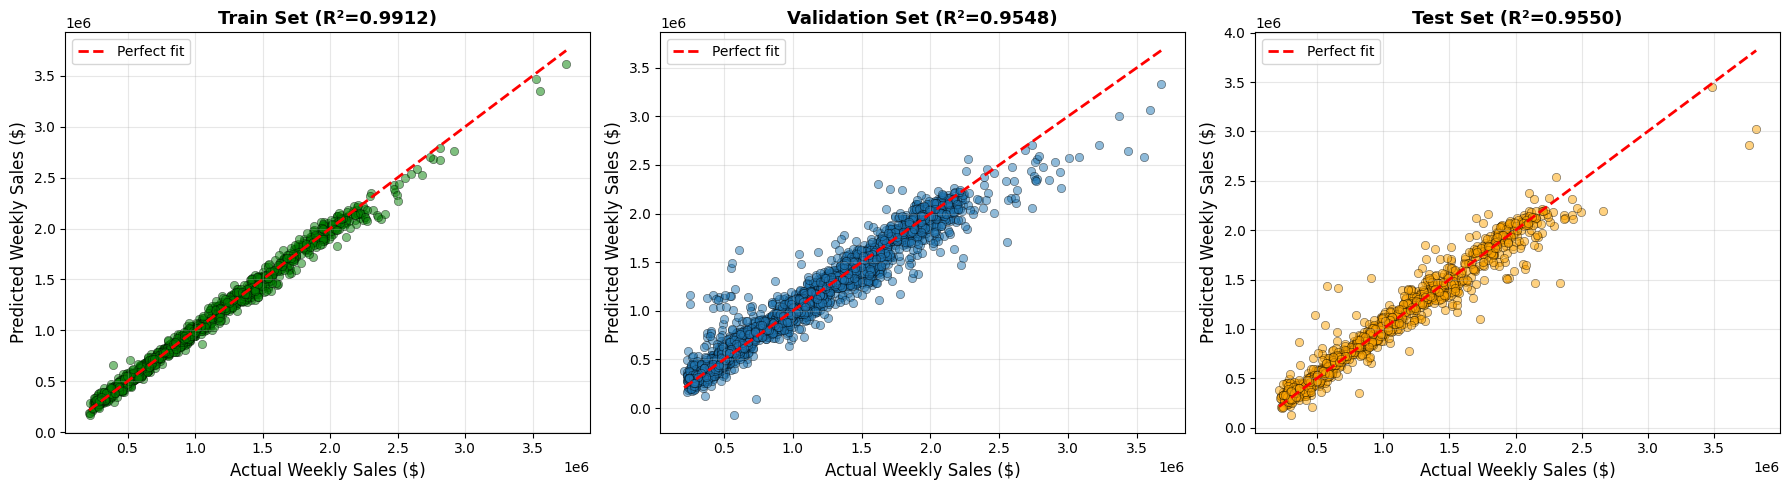

In [14]:
# 6) Parity Plot: Actual vs Predicted
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train parity plot
axes[0].scatter(y_train, preds_train, alpha=0.5, edgecolors='k', linewidth=0.5, color='green')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[0].set_title(f"Train Set (R²={metrics['TRAIN']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation parity plot
axes[1].scatter(y_val, preds_val, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[1].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[1].set_title(f"Validation Set (R²={metrics['VAL']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test parity plot
axes[2].scatter(y_test, preds_test, alpha=0.5, edgecolors='k', linewidth=0.5, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[2].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[2].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[2].set_title(f"Test Set (R²={metrics['TEST']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# 7) Model Configuration Summary
print('='*80)
print('XGBOOST REGRESSION MODEL CONFIGURATION SUMMARY')
print('='*80)

# 1) Selected Features
print('\n1. SELECTED FEATURES (11 total):')
print('-'*80)
for i, feat in enumerate(feature_cols, 1):
    print(f'   {i:2d}. {feat}')

# 2) Hyperparameters
print('\n2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):')
print('-'*80)
print('   Model: XGBRegressor (xgboost.sklearn.XGBRegressor)')
print('   Hyperparameter Optimization:')
print('      - Method: GridSearchCV with 5-fold cross-validation')
print('      - Search space:')
print('          n_estimators ∈ [200, 500]')
print('          max_depth ∈ [3, 6, 10]')
print('          learning_rate ∈ [0.05, 0.1]')
print('          subsample ∈ [0.8, 1.0]')
print('          colsample_bytree ∈ [0.8, 1.0]')
print('      - Scoring metric: R² (coefficient of determination)')
print(f"      - Best n_estimators: {best_params['n_estimators']}")
print(f"      - Best max_depth: {best_params['max_depth']}")
print(f"      - Best learning_rate: {best_params['learning_rate']}")
print(f"      - Best subsample: {best_params['subsample']}")
print(f"      - Best colsample_bytree: {best_params['colsample_bytree']}")
print(f"      - CV R² score: {cv_score:.4f}")
print('\n   Model Parameters:')
print(f'      - n_estimators: {xgb.n_estimators} (OPTIMIZED)')
print(f'      - max_depth: {xgb.max_depth} (OPTIMIZED)')
print(f'      - learning_rate: {xgb.learning_rate} (OPTIMIZED)')
print(f'      - subsample: {xgb.subsample} (OPTIMIZED)')
print(f'      - colsample_bytree: {xgb.colsample_bytree} (OPTIMIZED)')
print('      - random_state: 42')
print(f"      - tree_method: {getattr(xgb, 'tree_method', 'auto')}")
print('\n   Preprocessing:')
print("      - Imputation: SimpleImputer(strategy='median')")
print('      - Scaling: None (not required)')
print('      - Random seed: 42')

# 3) Feature Importances
print('\n3. FEATURE IMPORTANCES (gain-based from model.feature_importances_):')
print('-'*80)
print('\n   Feature Importances (sorted by importance):')
for idx, row in feature_importance.iterrows():
    bar_length = int(row['Importance'] * 50)  # Scale to 50 chars max
    bar = '█' * bar_length
    print(f"      {row['Feature']:20s}: {row['Importance']:6.4f}  {bar}")

print('\n' + '='*80)
print('INTERPRETATION:')
print('-'*80)
print('• Feature importances sum to 1.0 (approx.)')
print('• Boosting with learning_rate and many trees improves accuracy over single trees')
print('• Subsample and colsample_bytree help reduce overfitting')
print('• Monitor train vs validation R² to detect overfitting')
print('='*80)

XGBOOST REGRESSION MODEL CONFIGURATION SUMMARY

1. SELECTED FEATURES (11 total):
--------------------------------------------------------------------------------
    1. Holiday_Flag
    2. Temperature
    3. Fuel_Price
    4. CPI
    5. Unemployment
    6. Store_Encoded
    7. Month
    8. DayOfWeek
    9. Week
   10. Quarter
   11. IsWeekend

2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):
--------------------------------------------------------------------------------
   Model: XGBRegressor (xgboost.sklearn.XGBRegressor)
   Hyperparameter Optimization:
      - Method: GridSearchCV with 5-fold cross-validation
      - Search space:
          n_estimators ∈ [200, 500]
          max_depth ∈ [3, 6, 10]
          learning_rate ∈ [0.05, 0.1]
          subsample ∈ [0.8, 1.0]
          colsample_bytree ∈ [0.8, 1.0]
      - Scoring metric: R² (coefficient of determination)
      - Best n_estimators: 500
      - Best max_depth: 3
      - Best learning_rate: 0.1
      - Best subsample: 0.8

# 8) Reporting Results in Technical Papers

Use this section as a checklist/template to report XGBoost results rigorously and consistently across your paper.

## What to report

- Dataset and target
  - Source: Walmart weekly sales dataset
  - Target: Weekly_Sales (in US dollars; absolute-error metrics are $-denominated)
- Feature set
  - 11 predictors: Holiday_Flag, Temperature, Fuel_Price, CPI, Unemployment, Store_Encoded, Month, DayOfWeek, Week, Quarter, IsWeekend
- Data splits and reproducibility
  - Splits: 20% Train, 60% Validation, 20% Test (random_state = 42)
  - No leakage: Imputer fit on Train only, then applied to Val/Test
- Model and hyperparameter optimization
  - Model: XGBRegressor (tree-based boosting; no scaling required)
  - Optimization: GridSearchCV (5-fold, scoring = R²)
  - Tuned: n_estimators, max_depth, learning_rate, subsample, colsample_bytree
- Primary results to include
  - Test-set R² (primary) and RMSE/MAE in dollars
  - Validation-set metrics (for model selection) and Train-set metrics (for overfit check)
- Interpretation aids
  - Parity plots (Actual vs Predicted for Train/Val/Test)
  - Feature importances (gain-based)

## Tables and figures to include

- Metrics table (Train/Validation/Test):
  - Use: XGBoost_Regression_Metrics.csv
  - Columns: Dataset, R², MSE, RMSE ($), MAE ($)
- Hyperparameters table (final tuned values):
  - Use: XGBoost_Hyperparameters.csv
  - Include: n_estimators, max_depth, learning_rate, subsample, colsample_bytree, CV R²
- Feature importances table:
  - Use: XGBoost_Feature_Importances.csv
  - Report Top-5 and briefly discuss relevance
- Parity plots:
  - From the plotting cell in this notebook; include Train, Validation, and Test panels

## Suggested narrative (replace placeholders with your run’s values)

- Model selection and tuning
  - “We trained an XGBoost regressor on engineered calendar and economic features. Hyperparameters (n_estimators, max_depth, learning_rate, subsample, colsample_bytree) were optimized via 5-fold GridSearchCV using R².”
- Final configuration
  - “The best configuration was: n_estimators = [best_n], max_depth = [best_d], learning_rate = [best_lr], subsample = [best_sub], colsample_bytree = [best_col]. Cross-validated R² = [cv_r2].”
- Performance
  - “On the held-out Test set, the model achieved R² = [test_r2], RMSE = $[test_rmse], and MAE = $[test_mae]. Validation metrics were R² = [val_r2], RMSE = $[val_rmse], indicating [good/acceptable] generalization relative to training performance.”
- Overfitting check
  - “The Train–Validation R² gap was [gap], suggesting [limited/possible] overfitting; we mitigated this via depth control and subsampling.”
- Interpretation
  - “Top features included [feat1], [feat2], [feat3], based on model gain importances; this aligns with domain expectations for weekly sales.”

## Reproducibility notes

- Random seed: 42 for both splitting and XGBoost
- Preprocessing: SimpleImputer(strategy = 'median'); no scaling
- Exports for audit/Excel verification:
  - XGBoost_Regression_Metrics.csv
  - XGBoost_Hyperparameters.csv
  - XGBoost_Feature_Importances.csv
  - XGBoost_Train_Predictions.csv, XGBoost_Validation_Predictions.csv, XGBoost_Test_Predictions.csv

## Reporting tips

- Always cite the Test-set R² as the primary result, with RMSE/MAE in dollars for interpretability.
- Include the parity plot for the Test set to visually assess calibration and error spread.
- When comparing models (Ridge, Lasso, Tree, RF, SVR, XGBoost), use the same data splits and report all metrics from their exported CSVs for a fair comparison.